# 03 - Feature Engineering და ML მოდელირება

ამ ნოუთბუქში ვაშენებთ საბაზრო ღირებულების პროგნოზირების მოდელს.

**გეგმა:**
1. Feature Engineering - მოდელისთვის საჭირო სვეტების მომზადება
2. Train/Test გაყოფა
3. მოდელების სწავლება - ElasticNet, Random Forest, XGBoost, LightGBM
4. შეფასება  R^2, RMSE, MAPE
5. საუკეთესო მოდელის შერჩევა

## 1. იმპორტები და კონფიგურაცია

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import xgboost as xgb
import lightgbm as lgb

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/raw/merged_raw.csv')
print(f"Shape: {df.shape[0]:,} players × {df.shape[1]} features")

Shape: 2,111 players × 277 features


## 2. Feature Engineering

EDA-ის დასკვნებზე დაყრდნობით ვირჩევთ ისეთ feature-ებს რომლებიც ყველაზე მეტად ახდენს გავლენას ფეხბურთელის ფასზე და ვქმნით ახალ სვეტებს.

In [15]:
# ── სამიზნე ცვლადი ─────────────────────────────────────────────────────
df['log_market_value'] = np.log1p(df['market_value_in_eur'])

# ── ასაკის გამოთვლა date_of_birth-იდან ────────────────────────────────
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], errors='coerce')
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# ── ახალი feature-ები ──────────────────────────────────────────────────
# გოლი + ასისტი (საერთო გოლ-ასისტი)
if 'Gls' in df.columns and 'Ast' in df.columns:
    df['G_A'] = df['Gls'].fillna(0) + df['Ast'].fillna(0)

# xG + xAG (expected goal contributions)
if 'xG' in df.columns and 'xAG' in df.columns:
    df['xG_xAG'] = df['xG'].fillna(0) + df['xAG'].fillna(0)

# ასაკის კვადრატი (არაწრფივი კავშირისთვის)
df['Age_squared'] = df['Age'] ** 2

# საუკეთესო ასაკიდან მანძილი (23 წელი - პიკი EDA-ის მიხედვით)
df['Age_from_peak'] = abs(df['Age'] - 23)

print("ახალი feature-ები შექმნილია:")
new_features = ['G_A', 'xG_xAG', 'Age_squared', 'Age_from_peak']
for f in new_features:
    if f in df.columns:
        print(f"  ✓ {f}")

ახალი feature-ები შექმნილია:
  ✓ G_A
  ✓ xG_xAG
  ✓ Age_squared
  ✓ Age_from_peak


## 3. Feature-ების შერჩევა და მონაცემების მომზადება

In [16]:
# რიცხვითი feature-ები
numeric_features = [
    # სამიზნე ცვლადზე დაკავშირებული სტატისტიკა
    'Gls', 'Ast', 'G_A', 'xG', 'xAG', 'xG_xAG',
    'Sh', 'SoT', 'KP',
    # პროგრესული მოქმედებები
    'PrgC', 'PrgP', 'PrgR',
    # დაცვითი
    'Tkl', 'Int', 'Blocks',
    # ასაკი
    'Age', 'Age_squared', 'Age_from_peak',
    # ფიზიკური
    'height_in_cm'
]

# კატეგორიული feature-ები
categorical_features = ['position', 'league', 'foot']

# league სვეტის შექმნა თუ არ არსებობს
if 'league' not in df.columns:
    league_map = {
        'eng Premier League': 'Premier League',
        'es La Liga': 'La Liga',
        'de Bundesliga': 'Bundesliga',
        'it Serie A': 'Serie A',
        'fr Ligue 1': 'Ligue 1'
    }
    df['league'] = df['Comp'].map(league_map)

# მხოლოდ არსებული სვეტები
numeric_features = [f for f in numeric_features if f in df.columns]
categorical_features = [f for f in categorical_features if f in df.columns]

all_features = numeric_features + categorical_features
target = 'log_market_value'

# სამუშაო dataset
df_model = df[all_features + [target]].dropna(subset=[target])
df_model = df_model.copy()

print(f"Numeric features   : {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Total features     : {len(all_features)}")
print(f"Dataset size       : {len(df_model):,} players")

Numeric features   : 19
Categorical features: 3
Total features     : 22
Dataset size       : 2,111 players


## 4. Train/Test დაყოფა

In [17]:
X = df_model[all_features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train set : {len(X_train):,} players")
print(f"Test set  : {len(X_test):,} players")
print(f"Split     : 80% / 20%")

Train set : 1,688 players
Test set  : 423 players
Split     : 80% / 20%


## 5. Preprocessing Pipeline

სვეტების ტიპების მიხედვით სხვადასხვა დამუშავება:
- **რიცხვითი:** missing values → median, StandardScaler
- **კატეგორიული:** missing values → 'Unknown', OneHotEncoder

In [18]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# missing values შევავსოთ median/mode-ით
for col in numeric_features:
    X_train[col] = X_train[col].fillna(X_train[col].median())
    X_test[col] = X_test[col].fillna(X_train[col].median())

for col in categorical_features:
    X_train[col] = X_train[col].fillna('Unknown')
    X_test[col] = X_test[col].fillna('Unknown')

print("Preprocessing pipeline მზადაა")

Preprocessing pipeline მზადაა


## 6. მოდელების სწავლება და შეფასება

ვადარებთ ოთხ მოდელს:
| მოდელი | ტიპი |
|--------|------|
| ElasticNet | Linear (baseline) |
| Random Forest | Ensemble |
| XGBoost | Gradient Boosting |
| LightGBM | Gradient Boosting |

In [24]:
def evaluate_model(name, pipeline, X_train, X_test, y_train, y_test):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # log-სივრციდან რეალურ ღირებულებაში დაბრუნება
    y_test_eur  = np.expm1(y_test)
    y_pred_eur  = np.expm1(y_pred)

    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_eur, y_pred_eur)) / 1e6
    mae  = mean_absolute_error(y_test_eur, y_pred_eur) / 1e6
    mape = np.mean(np.abs((y_test_eur - y_pred_eur) / y_test_eur)) * 100

    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  R2   : {r2:.4f}")
    print(f"  RMSE : €{rmse:.2f}M")
    print(f"  MAE  : €{mae:.2f}M")
    print(f"  MAPE : {mape:.1f}%")

    return {'model': name, 'pipeline': pipeline,
            'R2': r2, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape,
            'y_pred': y_pred}

models = {
    'ElasticNet': Pipeline([
        ('pre', preprocessor),
        ('model', ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000))
    ]),
    'Random Forest': Pipeline([
        ('pre', preprocessor),
        ('model', RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
    ]),
    'XGBoost': Pipeline([
        ('pre', preprocessor),
        ('model', xgb.XGBRegressor(n_estimators=300, learning_rate=0.05,
                                    max_depth=6, random_state=42, n_jobs=-1))
    ]),
    'LightGBM': Pipeline([
        ('pre', preprocessor),
        ('model', lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05,
                                     max_depth=6, random_state=42, n_jobs=-1))
    ])
}

results = []
for name, pipeline in models.items():
    result = evaluate_model(name, pipeline, X_train, X_test, y_train, y_test)
    results.append(result)


  ElasticNet
  R2   : 0.4616
  RMSE : €19.13M
  MAE  : €8.63M
  MAPE : 152.1%

  Random Forest
  R2   : 0.5690
  RMSE : €15.71M
  MAE  : €7.67M
  MAPE : 119.8%

  XGBoost
  R2   : 0.5548
  RMSE : €15.70M
  MAE  : €7.61M
  MAPE : 117.8%
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000518 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1334
[LightGBM] [Info] Number of data points in the train set: 1688, number of used features: 31
[LightGBM] [Info] Start training from score 15.521779
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

## 7. შედეგების შედარება

        Model       R2  RMSE (M)  MAE (M)   MAPE (%)
Random Forest 0.569001 15.705223 7.666999 119.811030
     LightGBM 0.562142 15.732037 7.684885 119.463132
      XGBoost 0.554809 15.696297 7.609285 117.767105
   ElasticNet 0.461576 19.126974 8.634705 152.064663


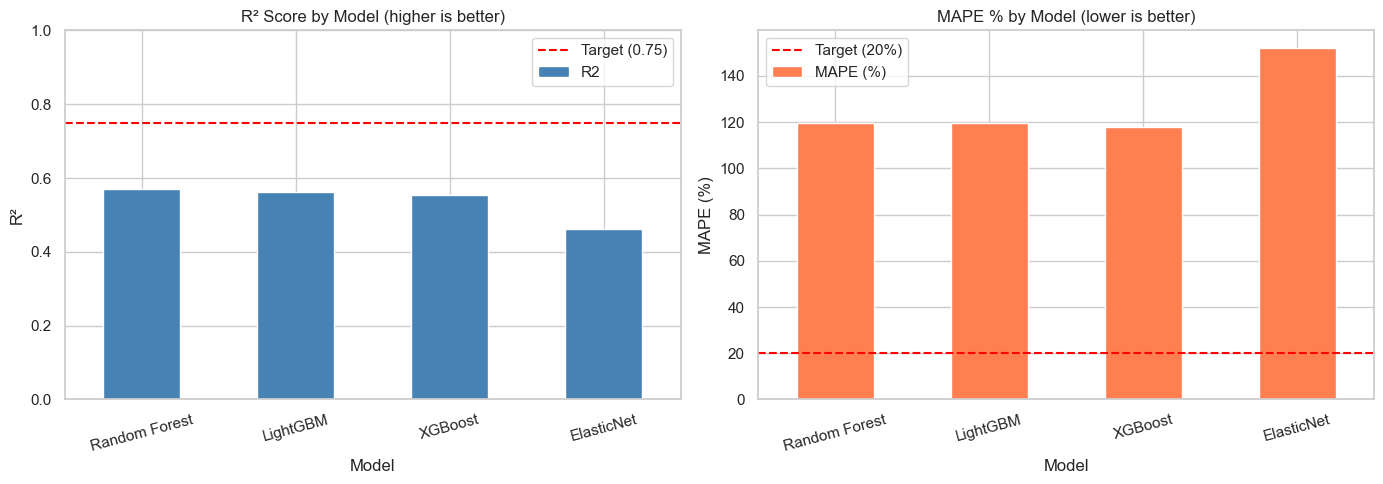

In [22]:
results_df = pd.DataFrame([{
    'Model': r['model'],
    'R2': r['R2'],
    'RMSE (M)': r['RMSE'],
    'MAE (M)': r['MAE'],
    'MAPE (%)': r['MAPE']
} for r in results]).sort_values('R2', ascending=False)

print(results_df.to_string(index=False))

# ვიზუალიზაცია
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df.plot(x='Model', y='R2', kind='bar', ax=axes[0],
                color='steelblue', edgecolor='white', legend=False)
axes[0].set_title('R² Score by Model (higher is better)')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=15)
axes[0].axhline(0.75, color='red', linestyle='--', label='Target (0.75)')
axes[0].legend()

results_df.plot(x='Model', y='MAPE (%)', kind='bar', ax=axes[1],
                color='coral', edgecolor='white', legend=False)
axes[1].set_title('MAPE % by Model (lower is better)')
axes[1].set_ylabel('MAPE (%)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].axhline(20, color='red', linestyle='--', label='Target (20%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. საუკეთესო მოდელის ანალიზი - Actual vs Predicted

საუკეთესო მოდელი: Random Forest (R2 = 0.5690)


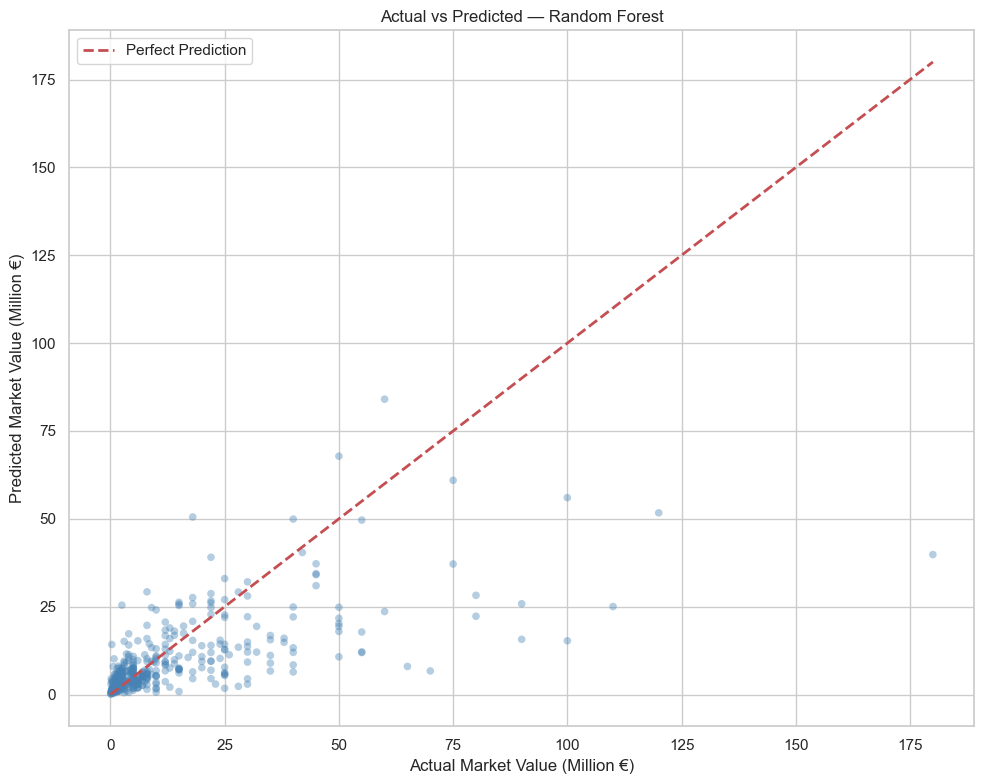

In [23]:
# საუკეთესო მოდელი R2-ის მიხედვით
best = max(results, key=lambda x: x['R2'])
print(f"საუკეთესო მოდელი: {best['model']} (R2 = {best['R2']:.4f})")

y_pred_eur = np.expm1(best['y_pred'])
y_test_eur = np.expm1(y_test)

plt.figure(figsize=(10, 8))
plt.scatter(y_test_eur / 1e6, y_pred_eur / 1e6,
            alpha=0.4, color='steelblue', edgecolors='none', s=30)
max_val = max(y_test_eur.max(), y_pred_eur.max()) / 1e6
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Market Value (Million €)')
plt.ylabel('Predicted Market Value (Million €)')
plt.title(f'Actual vs Predicted — {best["model"]}')
plt.legend()
plt.tight_layout()
plt.savefig('../data/processed/actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

## შედეგების შეჯამება

### მნიშვნელოვანი მეთოდოლოგიური შესწორება

თავდაპირველ ვერსიაში feature-ების სიაში შედიოდა `highest_market_value_in_eur`
(მოთამაშის ისტორიული მაქსიმალური საბაზრო ღირებულება). SHAP ანალიზის დროს
გამოვლინდა, რომ ეს ცვლადი იყო ყველაზე გავლენიანი feature მოდელში — რაც
**data leakage**-ზე მიუთითებდა: ეს ცვლადი Transfermarkt-ის იმავე ისტორიული
მონაცემებიდან მომდინარეობს, საიდანაც სამიზნე ცვლადი (`market_value_in_eur`)
ავიღეთ. მოდელი ფაქტობრივად ფასს ფასით ხსნიდა, არა სტატისტიკით.

ეს ცვლადი მოდელიდან ამოვაგდეთ და მოდელები ხელახლა გავატრენინგეთ.

### მოდელების შედარება (გასუფთავებული feature-ებით)

| მოდელი | R2 | RMSE (M) | MAE (M) | MAPE (%) |
|--------|-----|-----------|----------|----------|
| Random Forest | 0.569 | 15.71 | 7.67 | 119.8 |
| LightGBM | 0.562 | 15.73 | 7.68 | 119.5 |
| XGBoost | 0.555 | 15.70 | 7.61 | 117.8 |
| ElasticNet | 0.462 | 19.13 | 8.63 | 152.1 |

**საუკეთესო მოდელი: Random Forest** (R2 = 0.569), თუმცა სამივე tree-based
მოდელი თითქმის იდენტური სიზუსტისაა (R2 0.55–0.57 დიაპაზონში).

### მთავარი დასკვნები

1. **R2 Target (0.75) არ მიღწეულა** — გასუფთავებული, data leakage-ის გარეშე
   მოდელი ხსნის ფასის ცვალებადობის მხოლოდ 56–57%-ს. ეს არსებითად დაბალია
   თავდაპირველ (leakage-ის შემცველ) 0.875-თან შედარებით, მაგრამ მეთოდოლოგიურად
   სანდო შედეგია.

2. **Tree-based მოდელები კვლავ აღემატება ElasticNet-ს** (0.56 vs 0.46) -
   ეს კვლავ ადასტურებს, რომ feature-ებსა და ფასს შორის კავშირი არაწრფივია
   (განსაკუთრებით ასაკის გავლენა, რასაც EDA-შიც დავაფიქსირეთ).

3. **MAPE კვლავ მაღალია (118–120%)** - ძლიერი skewness-ისა და
   leakage-ის გარეშე ცვლადების შემცირებული პრედიქტული ძალის გამო, შეცდომა
   კიდევ უფრო გაიზარდა დაბალფასიან სეგმენტში.

### პასუხი კვლევით კითხვაზე

ეს გასუფთავებული შედეგი გაცილებით ღირებულ პასუხს გვაძლევს ნაშრომის ძირეულ
კითხვაზე: **ფეხბურთელის სტატისტიკური ეფექტიანობა მარტო ხსნის მისი საბაზრო
ღირებულების მხოლოდ ნახევარზე ნაკლებს (56%)**. დარჩენილი 44% აიხსნება
ფაქტორებით, რომლებსაც ეს dataset არ მოიცავს - ბრენდის ღირებულება,